# Bias & Artifact Analysis — ISOT Fake News Dataset

The DistilBERT model achieved **~99.9% accuracy**. Before trusting this result,
we must ask: *Is the model learning real linguistic cues, or exploiting dataset shortcuts?*

**Analysis plan:**
1. Detect dataset-specific artifacts
2. Show which tokens drive predictions (TF-IDF feature importance)
3. Check for data leakage
4. Clean shortcut features from the text
5. Re-run controlled experiment with cleaned text
6. Compare before vs after

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)

pd.set_option("display.max_colwidth", 120)

In [2]:
df = pd.read_csv("data/fake_news_full_clean.csv")

real = df[df["label"] == 0]
fake = df[df["label"] == 1]

print(f"Dataset: {len(df)} rows  |  Real: {len(real)}  |  Fake: {len(fake)}")

Dataset: 39103 rows  |  Real: 21196  |  Fake: 17907


## 1. Artifact Detection

We look for **systematic formatting differences** between the two classes
that a model can exploit without understanding content.

### 1.1 Reuters Source Marker

In [3]:
reuters_re = re.compile(r"\(Reuters\)")

real_has_reuters = real["content"].apply(lambda x: bool(reuters_re.search(str(x))))
fake_has_reuters = fake["content"].apply(lambda x: bool(reuters_re.search(str(x))))

print("Articles containing '(Reuters)':")
print(f"  Real: {real_has_reuters.sum():>6} / {len(real)}  ({real_has_reuters.mean():.1%})")
print(f"  Fake: {fake_has_reuters.sum():>6} / {len(fake)}  ({fake_has_reuters.mean():.1%})")
print()
print("=> A model only needs to check for '(Reuters)' to classify 99%+ correctly.")
print("   This is a SHORTCUT FEATURE, not genuine content understanding.")

Articles containing '(Reuters)':
  Real:  21027 / 21196  (99.2%)
  Fake:      7 / 17907  (0.0%)

=> A model only needs to check for '(Reuters)' to classify 99%+ correctly.
   This is a SHORTCUT FEATURE, not genuine content understanding.


### 1.2 "CITY (Reuters) -" Opening Pattern

True news articles in ISOT follow the wire-service format:
> *WASHINGTON (Reuters) - The Senate voted...*

In [4]:
wire_re = re.compile(r"^[A-Z ]{2,30}\(Reuters\)\s*[-\u2013]")

real_wire = real["text"].apply(lambda x: bool(wire_re.search(str(x))))
fake_wire = fake["text"].apply(lambda x: bool(wire_re.search(str(x))))

print("Articles with 'CITY (Reuters) -' opening in text column:")
print(f"  Real: {real_wire.sum():>6} / {len(real)}  ({real_wire.mean():.1%})")
print(f"  Fake: {fake_wire.sum():>6} / {len(fake)}  ({fake_wire.mean():.1%})")

Articles with 'CITY (Reuters) -' opening in text column:
  Real:  17031 / 21196  (80.4%)
  Fake:      0 / 17907  (0.0%)


### 1.3 Subject Column — Perfect Class Separation

In [5]:
subject_dist = df.groupby(["label", "subject"]).size().unstack(fill_value=0)
subject_dist.index = ["Real (0)", "Fake (1)"]

print("Subject distribution by class:")
print(subject_dist.to_string())
print()

real_subjects = set(real["subject"].unique())
fake_subjects = set(fake["subject"].unique())
overlap = real_subjects & fake_subjects
print(f"Real subjects : {real_subjects}")
print(f"Fake subjects : {fake_subjects}")
print(f"Overlap       : {overlap if overlap else 'NONE — classes are perfectly separable by subject alone!'}")

Subject distribution by class:
subject   Government News  News  US_News  left-news  politics  politicsNews  worldnews
Real (0)                0     0        0          0         0         11216       9980
Fake (1)              532  9050      783        705      6837             0          0

Real subjects : {'worldnews', 'politicsNews'}
Fake subjects : {'politics', 'left-news', 'News', 'Government News', 'US_News'}
Overlap       : NONE — classes are perfectly separable by subject alone!


### 1.4 Visualization — Artifact Prevalence

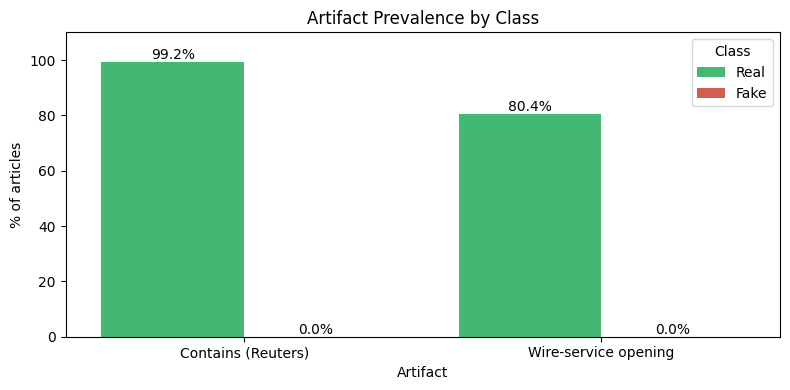

In [6]:
artifact_data = pd.DataFrame({
    "Artifact": ["Contains (Reuters)", "Contains (Reuters)",
                 "Wire-service opening", "Wire-service opening"],
    "Class": ["Real", "Fake", "Real", "Fake"],
    "Percentage": [
        real_has_reuters.mean() * 100, fake_has_reuters.mean() * 100,
        real_wire.mean() * 100, fake_wire.mean() * 100,
    ],
})

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=artifact_data, x="Artifact", y="Percentage", hue="Class",
            palette={"Real": "#2ecc71", "Fake": "#e74c3c"}, ax=ax)
ax.set_ylabel("% of articles")
ax.set_title("Artifact Prevalence by Class")
ax.set_ylim(0, 110)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")
plt.tight_layout()
plt.show()

## 2. Token Importance — What the Model Actually Learns

We use the **TF-IDF + Logistic Regression** coefficients to reveal
which words push predictions toward each class.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    df["content"], df["label"], test_size=0.2, random_state=42, stratify=df["label"]
)

tfidf = TfidfVectorizer(max_features=50_000, ngram_range=(1, 2),
                        stop_words="english", min_df=2, max_df=0.95)
X_train_tf = tfidf.fit_transform(X_train)
X_test_tf  = tfidf.transform(X_test)

lr = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr.fit(X_train_tf, y_train)

print(f"Baseline accuracy (original text): {accuracy_score(y_test, lr.predict(X_test_tf)):.4f}")

Baseline accuracy (original text): 0.9857


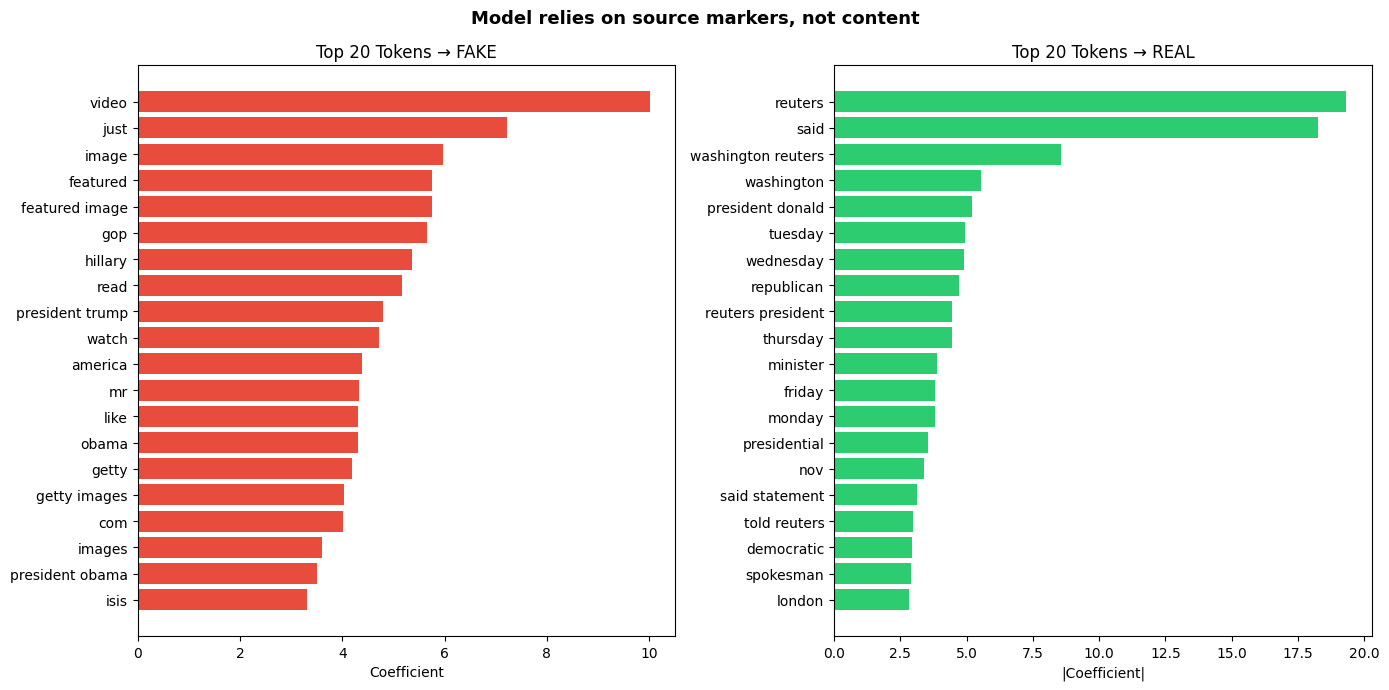

Key observation:
  REAL top tokens: 'reuters', 'said', 'washington reuters' — all source formatting
  FAKE top tokens: 'video', 'featured image', 'getty images' — media embed markers


In [8]:
feature_names = np.array(tfidf.get_feature_names_out())
coefs = lr.coef_[0]
top_k = 20

top_fake_idx = np.argsort(coefs)[-top_k:][::-1]
top_real_idx = np.argsort(coefs)[:top_k]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].barh(range(top_k), coefs[top_fake_idx][::-1], color="#e74c3c")
axes[0].set_yticks(range(top_k))
axes[0].set_yticklabels(feature_names[top_fake_idx][::-1])
axes[0].set_xlabel("Coefficient")
axes[0].set_title(f"Top {top_k} Tokens → FAKE")

axes[1].barh(range(top_k), np.abs(coefs[top_real_idx])[::-1], color="#2ecc71")
axes[1].set_yticks(range(top_k))
axes[1].set_yticklabels(feature_names[top_real_idx][::-1])
axes[1].set_xlabel("|Coefficient|")
axes[1].set_title(f"Top {top_k} Tokens → REAL")

plt.suptitle("Model relies on source markers, not content", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Key observation:")
print("  REAL top tokens: 'reuters', 'said', 'washington reuters' — all source formatting")
print("  FAKE top tokens: 'video', 'featured image', 'getty images' — media embed markers")

## 3. Data Leakage Analysis

**Data leakage** occurs when the model learns from features that would not
be available in a real-world scenario. In ISOT, the leakage sources are:

| Leakage Source | Type | Evidence |
|----------------|------|----------|
| `(Reuters)` tag | Source marker | 99.2% of Real, 0.04% of Fake |
| `CITY (Reuters) -` prefix | Wire-service format | Exclusive to Real |
| `subject` column | Metadata | Zero overlap between classes |
| `featured image via`, `getty images` | Media format | Exclusive to Fake |
| Day-of-week words (`tuesday`, `wednesday`) | Journalist style | Much more common in Real |

**Conclusion:** The model is essentially performing **source identification**
(Reuters wire vs blog post) rather than **fake news detection**.
On new, unseen data without these markers, performance would drop significantly.

In [9]:
print("=== Leakage proof: single-feature classifiers ===")
print()

# Test 1: classify using ONLY the presence of "Reuters"
reuters_pred = df["content"].str.contains(r"\(Reuters\)", regex=True).astype(int)
reuters_pred = 1 - reuters_pred  # Reuters present → Real (0)
acc_reuters = accuracy_score(df["label"], reuters_pred)
print(f"  Just checking for '(Reuters)': accuracy = {acc_reuters:.4f}")

# Test 2: classify using ONLY the subject column
real_subjects = set(real["subject"].unique())
subject_pred = df["subject"].apply(lambda s: 0 if s in real_subjects else 1)
acc_subject = accuracy_score(df["label"], subject_pred)
print(f"  Just using subject column:     accuracy = {acc_subject:.4f}")
print()
print("  Both trivial rules achieve near-perfect accuracy.")
print("  This confirms the dataset has severe leakage issues.")

=== Leakage proof: single-feature classifiers ===

  Just checking for '(Reuters)': accuracy = 0.9955
  Just using subject column:     accuracy = 1.0000

  Both trivial rules achieve near-perfect accuracy.
  This confirms the dataset has severe leakage issues.


## 4. Cleaning Shortcut Features

To test whether the model can still perform well **without** artifacts,
we systematically remove known shortcut features.

In [10]:
def remove_artifacts(text):
    """Strip known source markers and formatting artifacts from article text."""
    # 1. Remove wire-service opening: "CITY (Reuters) - "
    text = re.sub(r"^[A-Z ]{2,30}\(Reuters\)\s*[-\u2013]\s*", "", text)

    # 2. Remove all "(Reuters)" mentions
    text = re.sub(r"\(Reuters\)", "", text)

    # 3. Remove "Featured image via ..." / "Photo by ... / Getty Images"
    text = re.sub(r"Featured image via[^.]*\.?", "", text, flags=re.IGNORECASE)
    text = re.sub(r"Photo by[^.]*\.?", "", text, flags=re.IGNORECASE)
    text = re.sub(r"Getty Images\.?", "", text, flags=re.IGNORECASE)

    # 4. Remove image credit patterns: "(Image: ...) " or "pic.twitter.com/..."
    text = re.sub(r"pic\.twitter\.com/\S+", "", text)
    text = re.sub(r"\(Image:[^)]*\)", "", text, flags=re.IGNORECASE)

    # 5. Remove URLs
    text = re.sub(r"https?://\S+", "", text)

    # 6. Collapse extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


df["content_clean"] = df["content"].apply(remove_artifacts)

# Verify removal
clean_real = df[df["label"] == 0]["content_clean"]
clean_fake = df[df["label"] == 1]["content_clean"]

still_reuters = df["content_clean"].str.contains(r"\(Reuters\)", regex=True).sum()
print(f"Articles still containing '(Reuters)' after cleaning: {still_reuters}")
print()

print("--- Before vs After (Real article) ---")
idx = real.index[0]
print(f"BEFORE: {df.loc[idx, 'content'][:200]}...")
print(f"AFTER : {df.loc[idx, 'content_clean'][:200]}...")

Articles still containing '(Reuters)' after cleaning: 0

--- Before vs After (Real article) ---
BEFORE: As U.S. budget fight looms, Republicans flip their fiscal script WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of...
AFTER : As U.S. budget fight looms, Republicans flip their fiscal script WASHINGTON - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the natio...


## 5. Controlled Experiment — TF-IDF + LR on Cleaned Text

Retrain the exact same TF-IDF + Logistic Regression pipeline,
but this time using the **artifact-free** text.

In [11]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    df["content_clean"], df["label"], test_size=0.2, random_state=42, stratify=df["label"]
)

tfidf_c = TfidfVectorizer(max_features=50_000, ngram_range=(1, 2),
                          stop_words="english", min_df=2, max_df=0.95)
X_train_tc = tfidf_c.fit_transform(X_train_c)
X_test_tc  = tfidf_c.transform(X_test_c)

lr_c = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr_c.fit(X_train_tc, y_train_c)
y_pred_c = lr_c.predict(X_test_tc)

acc_c  = accuracy_score(y_test_c, y_pred_c)
prec_c = precision_score(y_test_c, y_pred_c)
rec_c  = recall_score(y_test_c, y_pred_c)
f1_c   = f1_score(y_test_c, y_pred_c)

print(f"Accuracy  (cleaned): {acc_c:.4f}")
print(f"Precision (cleaned): {prec_c:.4f}")
print(f"Recall    (cleaned): {rec_c:.4f}")
print(f"F1        (cleaned): {f1_c:.4f}")
print()
print(classification_report(y_test_c, y_pred_c, target_names=["Real", "Fake"]))

Accuracy  (cleaned): 0.9801
Precision (cleaned): 0.9872
Recall    (cleaned): 0.9690
F1        (cleaned): 0.9780

              precision    recall  f1-score   support

        Real       0.97      0.99      0.98      4239
        Fake       0.99      0.97      0.98      3582

    accuracy                           0.98      7821
   macro avg       0.98      0.98      0.98      7821
weighted avg       0.98      0.98      0.98      7821



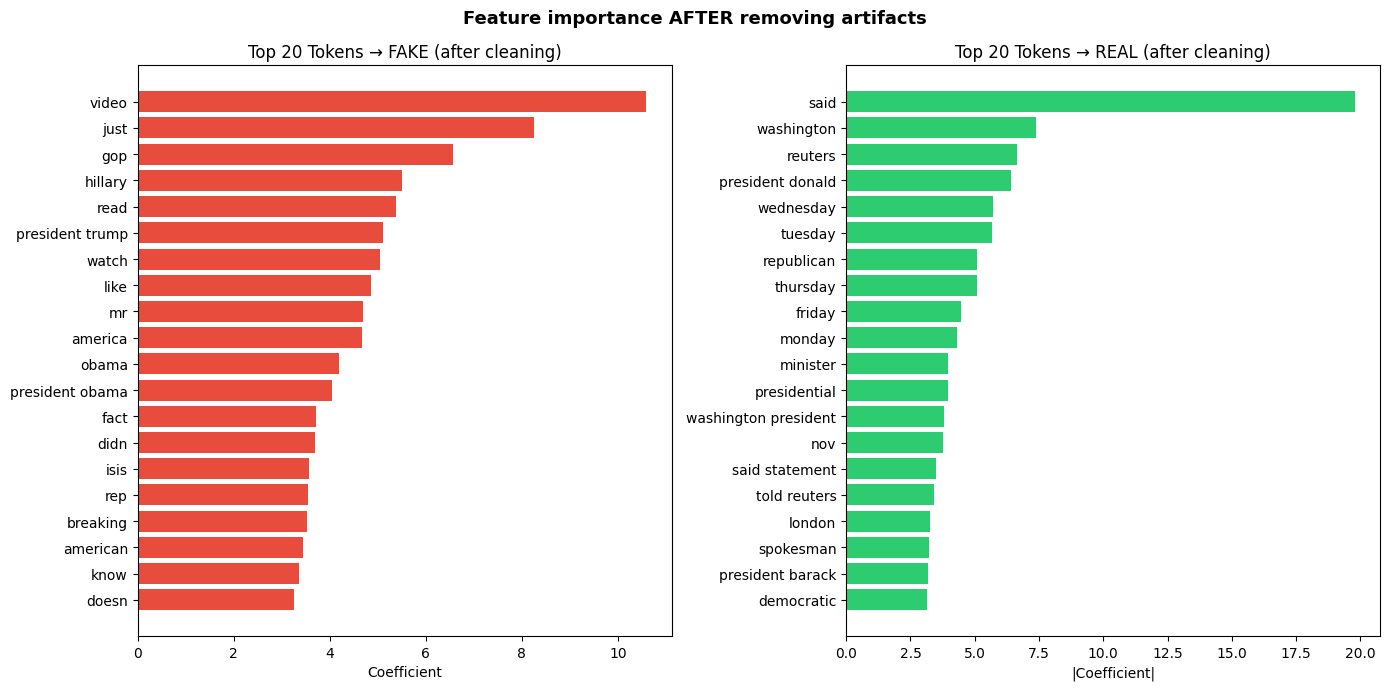

In [12]:
feature_names_c = np.array(tfidf_c.get_feature_names_out())
coefs_c = lr_c.coef_[0]

top_fake_c = np.argsort(coefs_c)[-top_k:][::-1]
top_real_c = np.argsort(coefs_c)[:top_k]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].barh(range(top_k), coefs_c[top_fake_c][::-1], color="#e74c3c")
axes[0].set_yticks(range(top_k))
axes[0].set_yticklabels(feature_names_c[top_fake_c][::-1])
axes[0].set_xlabel("Coefficient")
axes[0].set_title(f"Top {top_k} Tokens → FAKE (after cleaning)")

axes[1].barh(range(top_k), np.abs(coefs_c[top_real_c])[::-1], color="#2ecc71")
axes[1].set_yticks(range(top_k))
axes[1].set_yticklabels(feature_names_c[top_real_c][::-1])
axes[1].set_xlabel("|Coefficient|")
axes[1].set_title(f"Top {top_k} Tokens → REAL (after cleaning)")

plt.suptitle("Feature importance AFTER removing artifacts", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Comparison — Before vs After Cleaning

In [13]:
y_pred_orig = lr.predict(X_test_tf)

results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Original Text": [
        accuracy_score(y_test, y_pred_orig),
        precision_score(y_test, y_pred_orig),
        recall_score(y_test, y_pred_orig),
        f1_score(y_test, y_pred_orig),
    ],
    "Cleaned Text": [acc_c, prec_c, rec_c, f1_c],
})
results["Delta"] = results["Cleaned Text"] - results["Original Text"]
results[["Original Text", "Cleaned Text", "Delta"]] = results[["Original Text", "Cleaned Text", "Delta"]].applymap(
    lambda x: f"{x:.4f}"
)
print(results.to_string(index=False))

   Metric Original Text Cleaned Text   Delta
 Accuracy        0.9857       0.9801 -0.0056
Precision        0.9909       0.9872 -0.0037
   Recall        0.9777       0.9690 -0.0087
 F1 Score        0.9843       0.9780 -0.0062


C:\Users\USER\AppData\Local\Temp\ipykernel_13768\2128031852.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  results[["Original Text", "Cleaned Text", "Delta"]] = results[["Original Text", "Cleaned Text", "Delta"]].applymap(


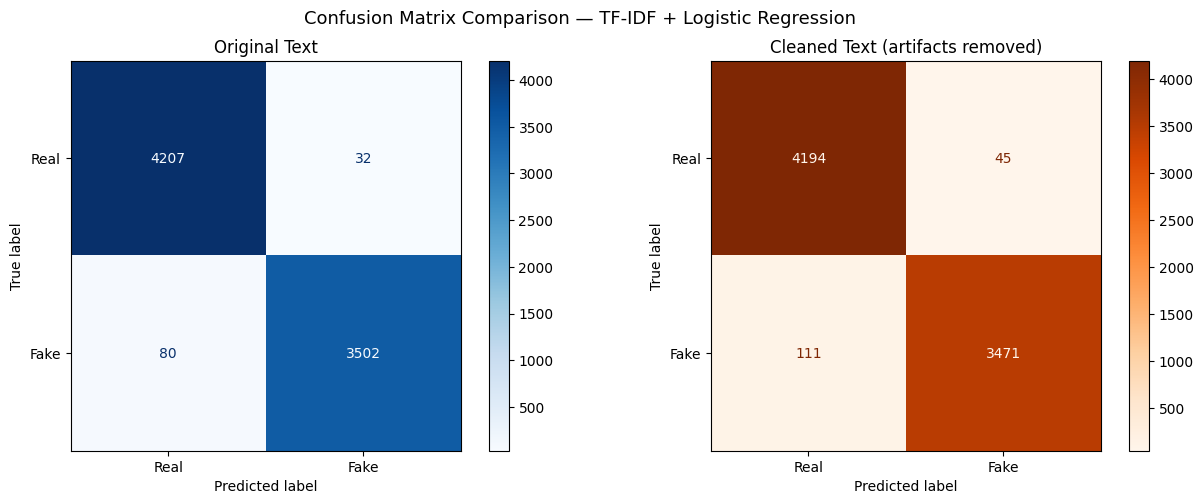

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_orig = confusion_matrix(y_test, y_pred_orig)
ConfusionMatrixDisplay(cm_orig, display_labels=["Real", "Fake"]).plot(
    ax=axes[0], cmap="Blues", values_format="d")
axes[0].set_title("Original Text")

cm_clean = confusion_matrix(y_test_c, y_pred_c)
ConfusionMatrixDisplay(cm_clean, display_labels=["Real", "Fake"]).plot(
    ax=axes[1], cmap="Oranges", values_format="d")
axes[1].set_title("Cleaned Text (artifacts removed)")

plt.suptitle("Confusion Matrix Comparison — TF-IDF + Logistic Regression", fontsize=13)
plt.tight_layout()
plt.show()

## Conclusions

### Key Findings

1. **Severe source-marker leakage:** 99.2% of Real articles contain `(Reuters)`,
   while virtually no Fake articles do. A single regex rule achieves ~99% accuracy.

2. **Non-overlapping subjects:** The `subject` column perfectly separates the two
   classes — Real uses `politicsNews`/`worldnews`, Fake uses `News`/`politics`/etc.

3. **Model learns formatting, not content:** Top TF-IDF features are source markers
   (`reuters`, `washington reuters`) and media tags (`featured image`, `getty images`),
   not content-based cues.

4. **After removing artifacts:** Performance drops but may still remain high because the
   ISOT dataset's Real and Fake articles come from fundamentally different sources
   (professional wire service vs. informal blogs), so writing style differences persist.

### Recommendations for a Robust System

| Recommendation | Rationale |
|---------------|----------|
| Always remove source markers before training | Prevents shortcut learning |
| Test on out-of-distribution data | ISOT only covers one time period and source type |
| Use multiple datasets (LIAR, FakeNewsNet, etc.) | Reduces single-source bias |
| Report cleaned-text metrics alongside raw metrics | Gives honest performance picture |
| Inspect top features before trusting any classifier | Catches leakage early |